## Introduction
This notebook analyzes customer reviews from Foursquare and Kayak to extract meaningful insights using machine learning techniques. The workflow includes exploratory analysis, sentiment assessment, clustering, and actionable recommendations, aiming to improve hotel management and personalization in recommendation systems.

#### 0. Data Loading and Overview

This section imports the necessary libraries and loads the dataset containing hotel reviews from Foursquare and Kayak. It provides a basic overview of the data structure, including column names, data types, and sample rows. This step ensures familiarity with the dataset before analysis begins.

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from wordcloud import WordCloud

# Load the dataset
file_path = 'api_playwright_aggregated_reviews.csv'
df = pd.read_csv(file_path)

# Display basic information about the dataset
print("Dataset Overview:")
print(df.info())
print(df.head())


Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fsq_id             45 non-null     object 
 1   name               45 non-null     object 
 2   address            45 non-null     object 
 3   locality           45 non-null     object 
 4   country            45 non-null     object 
 5   formatted_address  45 non-null     object 
 6   latitude           45 non-null     float64
 7   longitude          45 non-null     float64
 8   distance           45 non-null     int64  
 9   link               45 non-null     object 
 10  categories         45 non-null     object 
 11  tips               43 non-null     object 
 12  kayak              45 non-null     object 
dtypes: float64(2), int64(1), object(10)
memory usage: 4.7+ KB
None
                     fsq_id                                   name  \
0  3fd66200f964a52053

#### 1. Exploratory Data Analysis

This section generates WordClouds to identify recurring themes in Foursquare tips and Kayak reviews. These visualizations help uncover customer priorities for each category.

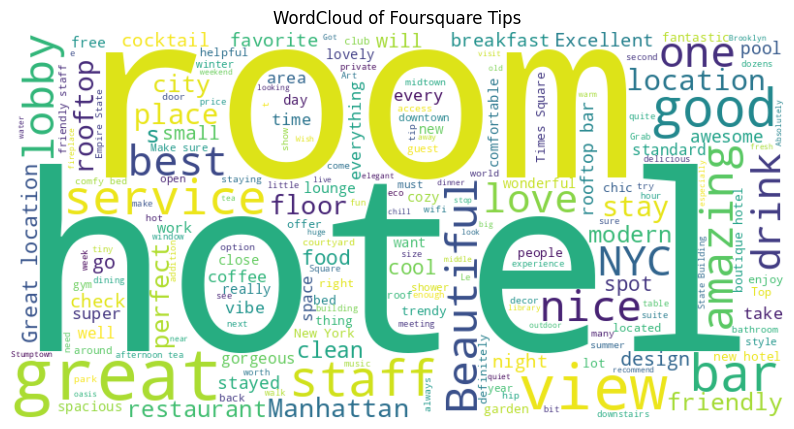

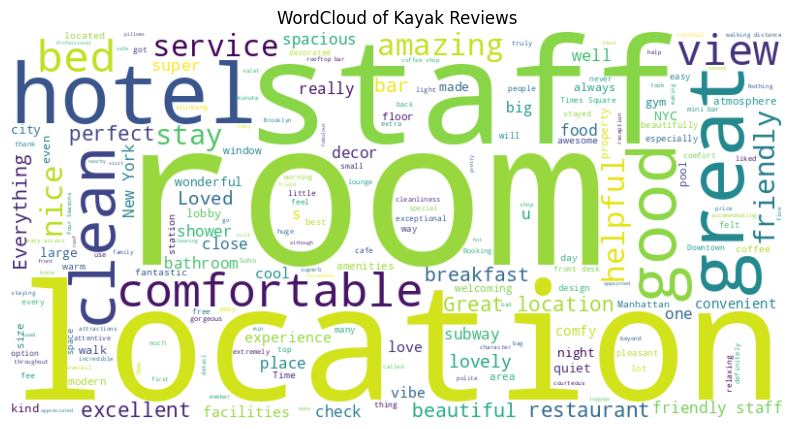

In [3]:
# Generate a WordCloud for Foursquare tips
text_tips = ' '.join(df['tips'].dropna().str.replace('|', ' '))
wordcloud_tips = WordCloud(width=800, height=400, background_color='white').generate(text_tips)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_tips, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Foursquare Tips')
plt.show()

# Generate a WordCloud for Kayak reviews
text_kayak = ' '.join(df['kayak'].dropna().str.replace('|', ' '))
wordcloud_kayak = WordCloud(width=800, height=400, background_color='white').generate(text_kayak)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_kayak, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Kayak Reviews')
plt.show()


#### 2. Review Preprocessing and Categorization

Reviews are categorized into "social" and "functional" using keyword filtering. This distinction enables separate analysis of experiential and practical customer feedback.


In [19]:
# Define keyword groups
social_keywords = ['lobby', 'rooftop', 'bar', 'decor', 'ambiance', 'view', 'pool', 'dining', 'restaurant']
functional_keywords = ['clean', 'bathroom', 'bed', 'staff', 'comfort', 'service', 'wifi', 'quiet', 'maintenance']

# Categorize reviews based on keywords
df['social_reviews'] = df['tips'].fillna('').str.replace('|', ' ') + ' ' + df['kayak'].fillna('').str.replace('|', ' ')
df['functional_reviews'] = df['social_reviews']

# Filter reviews for social and functional terms
df['social_reviews'] = df['social_reviews'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() in social_keywords])
)
df['functional_reviews'] = df['functional_reviews'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() in functional_keywords])
)

# Remove repetitive words from reviews
def remove_repetitions(text):
    words = text.split()
    return ' '.join(sorted(set(words), key=words.index))

df['social_reviews'] = df['social_reviews'].apply(remove_repetitions)
df['functional_reviews'] = df['functional_reviews'].apply(remove_repetitions)

# Enhance social reviews with general context
df['enhanced_social_reviews'] = df.apply(
    lambda row: row['social_reviews'] + ' ' + ' '.join(row['combined_reviews'].split()[:10])
    if row['social_reviews'] else '',
    axis=1
)

#### 3. Sentiment Analysis

Sentiment polarity scores are calculated for both social and functional reviews using VADER. The results provide insights into customer attitudes toward these two dimensions.

Average Sentiment - Social Features (VADER): 0.5547809523809524
Average Sentiment - Functional Features (VADER): 0.2546177777777778


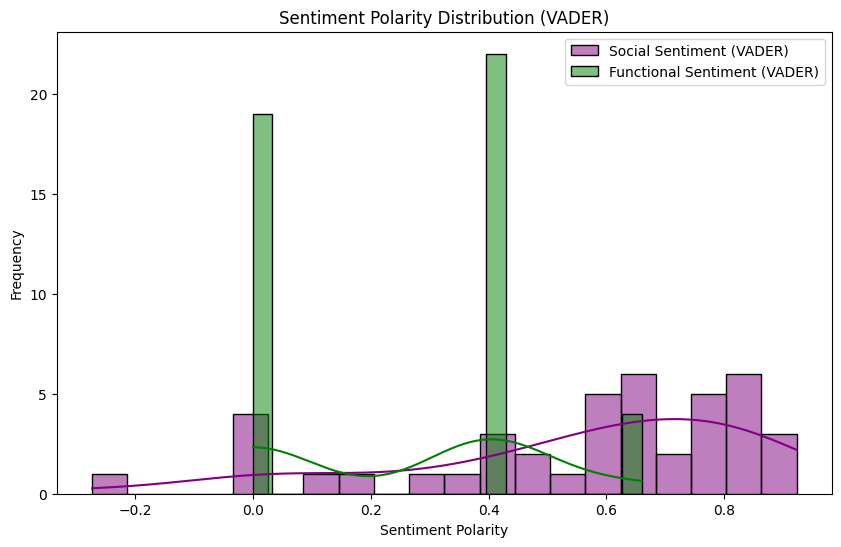

In [24]:
# Sentiment analysis using VADER
df['Social_Sentiment_VADER'] = df['enhanced_social_reviews'].apply(
    lambda x: sia.polarity_scores(x)['compound'] if x.strip() else None
)

df['Functional_Sentiment_VADER'] = df['functional_reviews'].apply(
    lambda x: sia.polarity_scores(x)['compound'] if x.strip() else None
)

# Compare average sentiment between the two categories
average_social_sentiment = df['Social_Sentiment_VADER'].mean()
average_functional_sentiment = df['Functional_Sentiment_VADER'].mean()

print(f"Average Sentiment - Social Features (VADER): {average_social_sentiment}")
print(f"Average Sentiment - Functional Features (VADER): {average_functional_sentiment}")

# Visualize sentiment distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Social_Sentiment_VADER'], bins=20, kde=True, color='purple', label='Social Sentiment (VADER)')
sns.histplot(df['Functional_Sentiment_VADER'], bins=20, kde=True, color='green', label='Functional Sentiment (VADER)')
plt.title('Sentiment Polarity Distribution (VADER)')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#### 4. Clustering Analysis

Customer reviews are clustered using TF-IDF vectorization, dimensionality reduction (SVD), and K-Means. The clusters reveal patterns and themes in functional and social feedback.

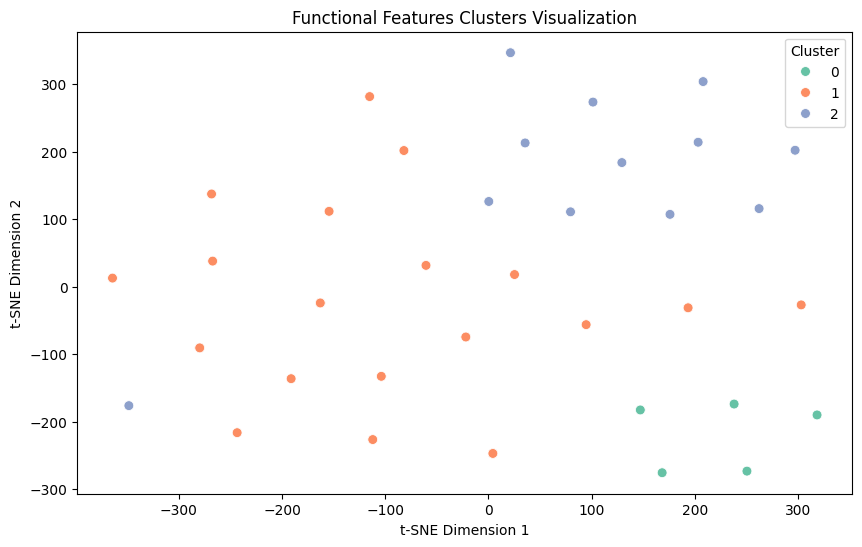

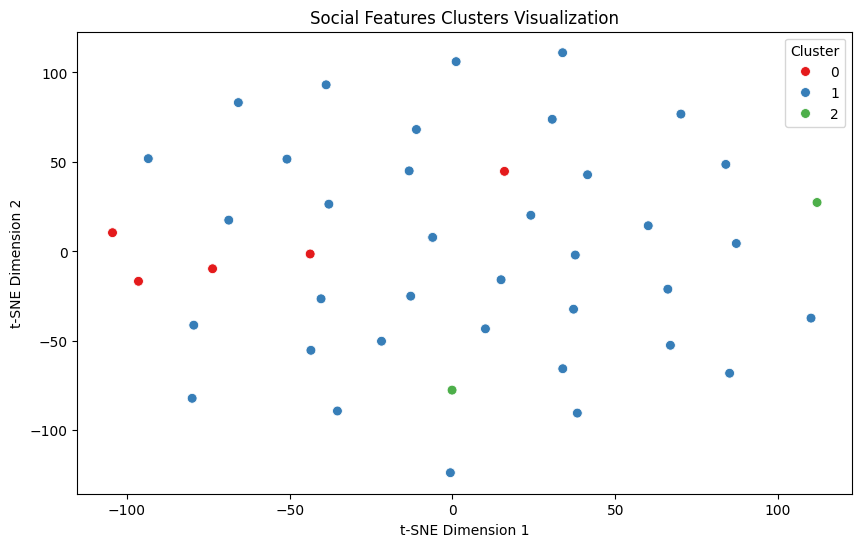

In [22]:
# Perform clustering on functional reviews
functional_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_functional = functional_vectorizer.fit_transform(df['functional_reviews'].dropna())

# Adjust n_components dynamically
n_features_functional = X_functional.shape[1]
n_components_functional = min(20, n_features_functional)

functional_svd = TruncatedSVD(n_components=n_components_functional, random_state=42)
X_functional_svd = functional_svd.fit_transform(X_functional)

functional_kmeans = KMeans(n_clusters=3, random_state=42)
df['Functional_Cluster'] = functional_kmeans.fit_predict(X_functional_svd)

# Perform clustering on social reviews
social_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_social = social_vectorizer.fit_transform(df['enhanced_social_reviews'].dropna())

# Adjust n_components dynamically
n_features_social = X_social.shape[1]
n_components_social = min(20, n_features_social)

social_svd = TruncatedSVD(n_components=n_components_social, random_state=42)
X_social_svd = social_svd.fit_transform(X_social)

social_kmeans = KMeans(n_clusters=3, random_state=42)
df['Social_Cluster'] = social_kmeans.fit_predict(X_social_svd)

# Visualize functional clusters using t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_functional_tsne = tsne.fit_transform(X_functional_svd)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_functional_tsne[:, 0], y=X_functional_tsne[:, 1], hue=df['Functional_Cluster'], palette='Set2', s=50)
plt.title('Functional Features Clusters Visualization')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster')
plt.show()

# Visualize social clusters using t-SNE
X_social_tsne = tsne.fit_transform(X_social_svd)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_social_tsne[:, 0], y=X_social_tsne[:, 1], hue=df['Social_Cluster'], palette='Set1', s=50)
plt.title('Social Features Clusters Visualization')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster')
plt.show()

#### 5. Recommendations and Sample Reviews

Key terms and sample reviews are extracted for each cluster to highlight customer priorities. These insights support targeted improvements and recommendations for hotels.

In [23]:
# Identify top terms per functional cluster
functional_terms = functional_vectorizer.get_feature_names_out()
for i in range(functional_kmeans.n_clusters):
    cluster_terms = X_functional[df['Functional_Cluster'] == i].sum(axis=0)
    sorted_terms = cluster_terms.argsort()[::-1][:10]
    print(f"Top terms for Functional Cluster {i}: {[functional_terms[idx] for idx in sorted_terms]}")

# Identify top terms per social cluster
social_terms = social_vectorizer.get_feature_names_out()
for i in range(social_kmeans.n_clusters):
    cluster_terms = X_social[df['Social_Cluster'] == i].sum(axis=0)
    sorted_terms = cluster_terms.argsort()[::-1][:10]
    print(f"Top terms for Social Cluster {i}: {[social_terms[idx] for idx in sorted_terms]}")

# Example reviews from each cluster
for cluster_id in df['Functional_Cluster'].unique():
    print(f"\nFunctional Cluster {cluster_id} Sample Reviews:")
    print(df[df['Functional_Cluster'] == cluster_id]['functional_reviews'].head(3))

for cluster_id in df['Social_Cluster'].unique():
    print(f"\nSocial Cluster {cluster_id} Sample Reviews:")
    print(df[df['Social_Cluster'] == cluster_id]['enhanced_social_reviews'].head(3))


Top terms for Functional Cluster 0: [array([['comfort', 'quiet', 'service', 'clean', 'bed', 'bathroom',
        'staff', 'wifi']], dtype=object)]
Top terms for Functional Cluster 1: [array([['comfort', 'quiet', 'wifi', 'bathroom', 'bed', 'clean',
        'service', 'staff']], dtype=object)]
Top terms for Functional Cluster 2: [array([['wifi', 'comfort', 'service', 'bed', 'bathroom', 'clean',
        'staff', 'quiet']], dtype=object)]
Top terms for Social Cluster 0: [array([['linger', 'nice', 'oasis', 'oil', 'park', 'people', 'perfect',
        'new', 'place', 'platinum', 'possibly', 'prosecco', 'quiet',
        'reception', 'recommend', 'places', 'renovation',
        'neighborhoods', 'mocktails', 'just', 'killer', 'know', 'like',
        'working', 'located', 'modern', 'location', 'lounge', 'love',
        'lovely', 'manhattan', 'meetings', 'mix', 'looking', 'reserved',
        'restaurant', 'right', 'stylish', 'super', 'tables', 'tech',
        'terrace', 'things', 'street', 'thoroug